# Análise de Clustering com Idade e Profissão

## Carregamento de Dados

In [54]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

dim_cliente= pd.read_csv("../Dados Finais/dim_cliente.csv", encoding="utf-8")
fact_cliente= pd.read_csv("../Dados Finais/tf_cliente.csv", encoding="utf-8")

## Agregação de Dados e Preparação das Features

In [55]:
# Agregação de dados por cliente
agg = fact_cliente.groupby('sk_cliente').agg(
    n_idas=('fact_id', 'count'),
    tempo_medio=('tempo_permanencia', 'mean'),
    calorias_media=('calorias_queimadas', 'mean'),
    n_treinos=('sk_treino', lambda x: x.notna().sum()),
    n_aulas=('sk_aula', lambda x: x.notna().sum()),
    avaliacao_treino_media=('avaliacao_treino', 'mean'),
    avaliacao_aula_media=('avaliacao_aula', 'mean')
).reset_index()

# Calcular idade
dim_cliente['cliente_data_nascimento'] = pd.to_datetime(dim_cliente['cliente_data_nascimento'], errors='coerce')
ref_date = pd.to_datetime("2025-09-30")
dim_cliente['idade'] = dim_cliente['cliente_data_nascimento'].apply(
    lambda x: ref_date.year - x.year if pd.notnull(x) else None
)

# Merge com dimensão cliente
features = agg.merge(dim_cliente, left_on='sk_cliente', right_on='cliente_sk', how='left')

# Calcular IMC
features['imc'] = features['cliente_peso_kg'] / ((features['cliente_altura_cm'] / 100) ** 2)

## Seleção e Tratamento de Features

In [56]:
# Seleção das features para clustering
features_clustering = features[[
    'n_idas', 'tempo_medio', 'calorias_media', 'n_treinos', 'n_aulas',
    'avaliacao_treino_media', 'avaliacao_aula_media', 'imc', 'idade',
    'cliente_faixa_etaria'
]]

# Preencher valores nulos
for col in ['tempo_medio', 'calorias_media', 'avaliacao_treino_media', 'avaliacao_aula_media', 'imc', 'idade']:
    features_clustering[col] = features_clustering[col].fillna(features_clustering[col].mean())
features_clustering['cliente_faixa_etaria'] = features_clustering['cliente_faixa_etaria'].fillna('Desconhecido')

# One-hot encoding para faixa etária
try:
    ohe = OneHotEncoder(sparse_output=False, drop='first')
except TypeError:
    ohe = OneHotEncoder(sparse=False, drop='first')
faixa_encoded = ohe.fit_transform(features_clustering[['cliente_faixa_etaria']])
faixa_encoded_df = pd.DataFrame(faixa_encoded, columns=ohe.get_feature_names_out(['cliente_faixa_etaria']))

# Normalizar variáveis numéricas
num_cols = ['n_idas', 'tempo_medio', 'calorias_media', 'n_treinos', 'n_aulas',
            'avaliacao_treino_media', 'avaliacao_aula_media', 'imc', 'idade']
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_clustering[num_cols])
features_scaled_df = pd.DataFrame(features_scaled, columns=num_cols)

# Concatenar para criar X
X = pd.concat([features_scaled_df, faixa_encoded_df], axis=1)

C:\Users\afons\AppData\Local\Temp\ipykernel_14588\1088325165.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features_clustering[col] = features_clustering[col].fillna(features_clustering[col].mean())
C:\Users\afons\AppData\Local\Temp\ipykernel_14588\1088325165.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features_clustering['cliente_faixa_etaria'] = features_clustering['cliente_faixa_etaria'].fillna('Desconhecido')


## KMeans e Avaliação de k

In [57]:
wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

# Plot Elbow e Silhouette
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(k_range, wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Número de clusters (k)')
plt.ylabel('WCSS')

plt.subplot(1,2,2)
plt.plot(k_range, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Score')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.savefig('../Imagens ProjetoPerfil/elbow_silhouette.png')
plt.close()

## Clustering Final e Análise de Resultados

In [62]:
# Aplicar KMeans com k=6
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)


cols_a_excluir = ['sk_cliente', 'cliente_id', 'cliente_sk']
features_filtrado = features.drop(columns=[col for col in cols_a_excluir if col in features.columns])
features['cluster'] = labels

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# X deve ser o mesmo dataset usado para o clustering (já normalizado e com dummies)
# labels são os rótulos atribuídos aos clientes pelo K-Means

# 1. Silhouette Score (quanto mais próximo de 1, melhor)
sil_score = silhouette_score(X, labels)

# 2. Davies-Bouldin Index (quanto mais baixo, melhor)
db_index = davies_bouldin_score(X, labels)

# 3. Calinski-Harabasz Index (quanto mais alto, melhor)
ch_score = calinski_harabasz_score(X, labels)

print(f"Silhouette Score: {sil_score:.3f}")
print(f"Davies-Bouldin Index: {db_index:.3f}")
print(f"Calinski-Harabasz Score: {ch_score:.3f}")

Silhouette Score: 0.135
Davies-Bouldin Index: 1.777
Calinski-Harabasz Score: 12.668


## Profissões mais comuns por cluster

In [59]:
top5_profissoes_por_cluster = (
    features.groupby('cluster')['cliente_profissao']
    .value_counts()
    .groupby(level=0)
    .head(3)
    .reset_index(name='frequencia')
)

# Organizar para visualização mais clara
display(top5_profissoes_por_cluster)

,cluster,cliente_profissao,frequencia
0,0,Dentista,2
1,0,Médico,2
2,0,Contabilista,1
3,1,Designer,3
4,1,Arquiteto,3
5,1,Médico,3
6,2,Psicólogo,2
7,2,Gestor,2
8,2,Designer,2
9,3,Psicólogo,2


## Gráficos de Análise

cluster
0    10
1    25
2    13
3    18
4    21
5    13
Name: count, dtype: int64

,n_idas,tempo_medio,calorias_media,n_treinos,n_aulas,avaliacao_treino_media,avaliacao_aula_media,cliente_altura_cm,cliente_peso_kg,idade,imc
cluster,,,,,,,,,,,
0,10.100000,1.885278,448.033532,0.300000,10.000000,5.000000,2.805000,173.100000,71.800000,42.400000,23.981333
1,9.720000,1.657820,904.845593,9.520000,9.240000,3.120524,3.100725,175.080000,79.520000,40.600000,26.095249
2,8.230769,2.151038,565.378907,5.307692,4.615385,3.791667,2.391667,162.538462,92.769231,43.384615,35.363507
3,9.333333,1.952502,555.192248,7.555556,2.944444,2.601961,3.348485,178.166667,73.388889,56.944444,23.302739
4,14.523810,2.007901,619.419438,11.428571,7.142857,3.321542,3.380556,175.238095,72.857143,49.523810,24.251644
5,8.846154,2.042110,536.668993,7.846154,1.692308,1.760073,2.250000,176.846154,84.846154,29.769231,27.592513


C:\Users\afons\AppData\Local\Temp\ipykernel_14588\1511139488.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=features, x='cluster', palette='tab10')


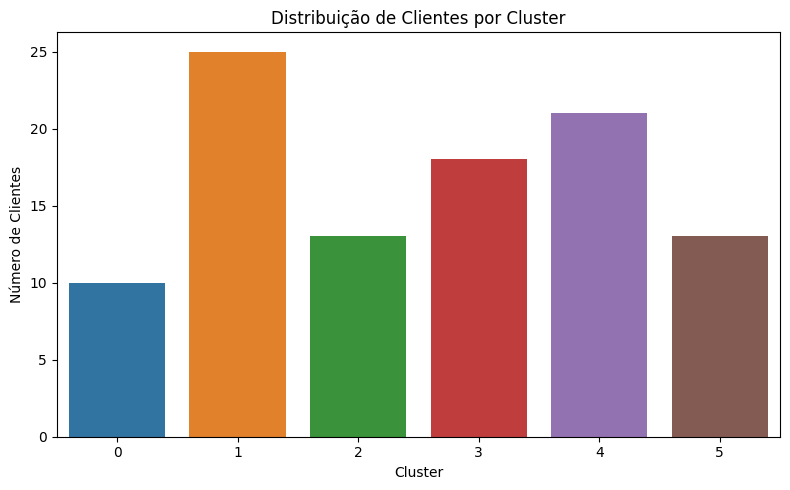

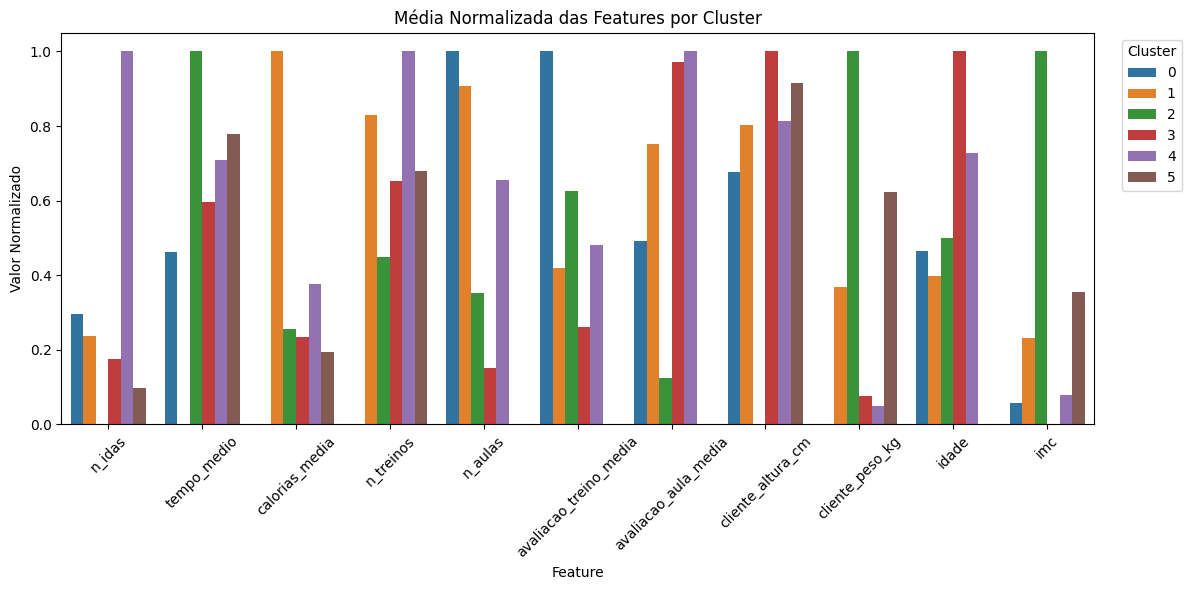

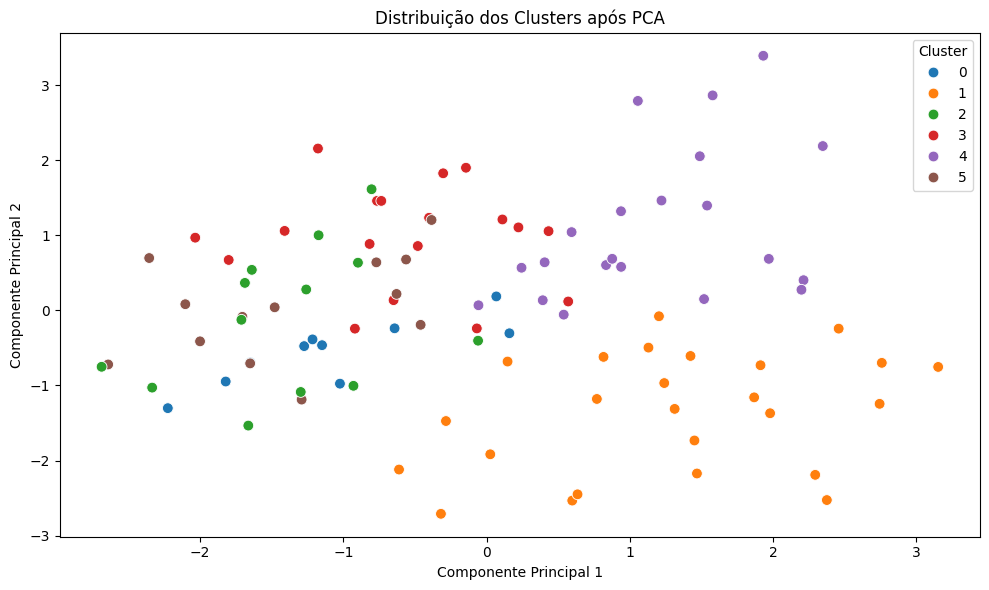

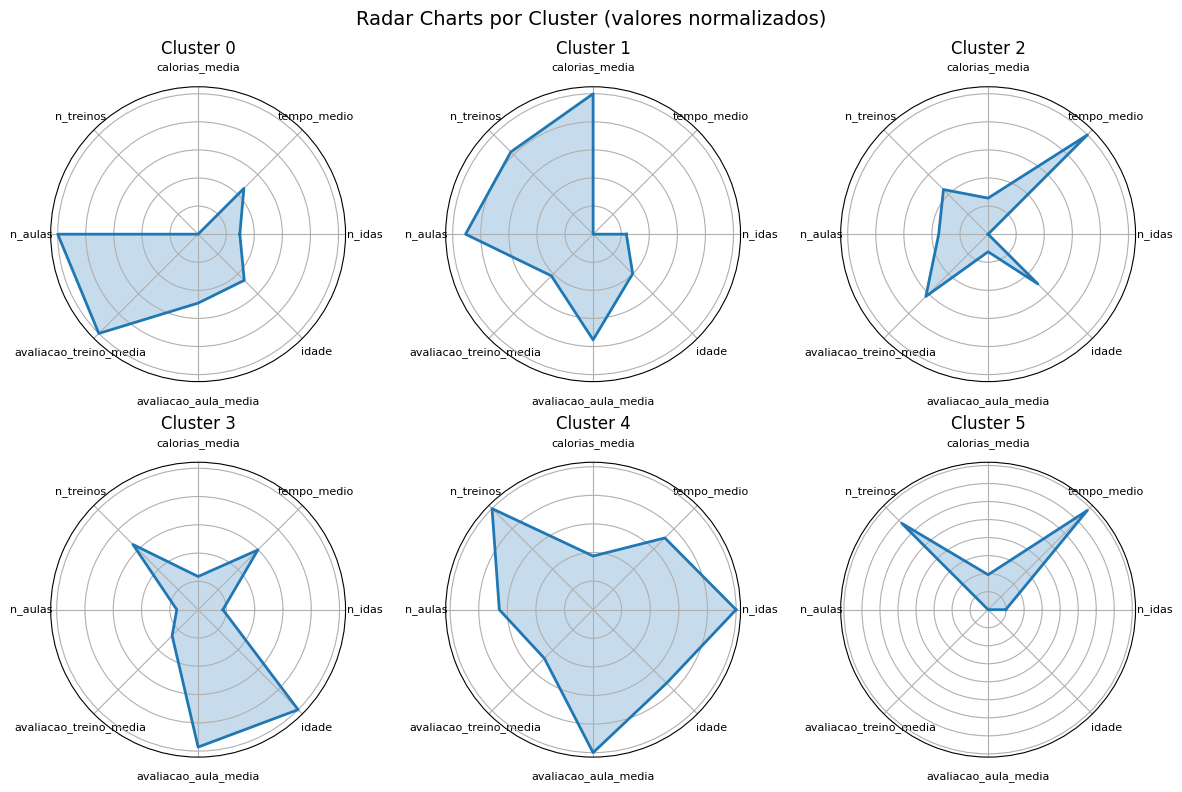

In [63]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

#DISTRIBUIÇÃO
distribuicao = features['cluster'].value_counts().sort_index()
medias_clusters = features_filtrado.groupby('cluster').mean(numeric_only=True)
display(distribuicao)
display(medias_clusters)
plt.figure(figsize=(8, 5))
sns.countplot(data=features, x='cluster', palette='tab10')
plt.title("Distribuição de Clientes por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Número de Clientes")
plt.tight_layout()
plt.show()


##############################################################################################
## GRÁFICO DAS MÉDIAS
# Remover colunas de identificação e PCA
id_cols = ['sk_cliente', 'cliente_id', 'cliente_sk']
pca_cols = [col for col in features.columns if col.startswith('pca_')]
excluir = id_cols + pca_cols + ['cluster']
numeric_cols = features.select_dtypes(include='number').columns
feature_cols = [col for col in numeric_cols if col not in excluir]

# Médias por cluster
medias_cluster = features.groupby('cluster')[feature_cols].mean()

# Normalizar para comparação visual
scaler = MinMaxScaler()
medias_norm = pd.DataFrame(
    scaler.fit_transform(medias_cluster),
    columns=feature_cols,
    index=medias_cluster.index
)

# Reorganizar para gráfico de colunas
medias_melted = medias_norm.reset_index().melt(id_vars='cluster', var_name='feature', value_name='media_normalizada')

# Gráfico de colunas agrupadas
plt.figure(figsize=(12, 6))
sns.barplot(data=medias_melted, x='feature', y='media_normalizada', hue='cluster', palette='tab10')
plt.title("Média Normalizada das Features por Cluster")
plt.xlabel("Feature")
plt.ylabel("Valor Normalizado")
plt.xticks(rotation=45)
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

#############################################################################
## GRÁFICO DA SEPARAÇÃO DOS CLUSTERS

# Reduzir para 2 componentes principais
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Adicionar ao dataframe
features['pca_1'] = X_pca[:, 0]
features['pca_2'] = X_pca[:, 1]

# Plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=features, x='pca_1', y='pca_2', hue='cluster', palette='tab10', s=60)
plt.title("Distribuição dos Clusters após PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# Variáveis a usar
vars_radar = ['n_idas', 'tempo_medio', 'calorias_media', 'n_treinos', 'n_aulas',
              'avaliacao_treino_media', 'avaliacao_aula_media', 'idade']

# Médias por cluster
medias = features.groupby('cluster')[vars_radar].mean()
scaler = MinMaxScaler()
medias_norm = pd.DataFrame(scaler.fit_transform(medias), columns=vars_radar, index=medias.index)

# Definir ângulos para os eixos
labels = vars_radar
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # fechar gráfico

# Criar subplots
n_clusters = medias_norm.shape[0]
cols = 3  # ajustar consoante o nº de clusters
rows = (n_clusters + cols - 1) // cols

fig, axs = plt.subplots(rows, cols, subplot_kw={'projection': 'polar'}, figsize=(cols*4, rows*4))
axs = axs.flatten()

# Gerar gráfico para cada cluster
for idx, cluster in enumerate(medias_norm.index):
    values = medias_norm.loc[cluster].tolist()
    values += values[:1]  # fechar loop

    ax = axs[idx]
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)
    ax.set_title(f"Cluster {cluster}")
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_yticklabels([])

# Apagar plots vazios
for j in range(idx+1, len(axs)):
    fig.delaxes(axs[j])

plt.suptitle("Radar Charts por Cluster (valores normalizados)", fontsize=14)
plt.tight_layout()
plt.show()